In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.expand_frame_repr', False)

conn = sqlite3.connect('Chinook_Sqlite.sqlite')

In [4]:
#1: Which are the 10 best-selling tracks?

query = """
SELECT
    t.name as track_name,
    t.trackid as track_id,
    SUM(il.quantity) as total_sold
FROM 
    Track t
JOIN
    InvoiceLine il
ON
    il.trackid = t.trackid
GROUP BY
    track_id,
    track_name    
ORDER BY
    total_sold DESC
LIMIT
    10"""

df = pd.read_sql_query(query, conn)

df


,track_name,track_id,total_sold
0,Balls to the Wall,2,2
1,Inject The Venom,8,2
2,Snowballed,9,2
3,Overdose,20,2
4,Deuces Are Wild,32,2
5,Not The Doctor,48,2
6,Por Causa De Você,66,2
7,Welcome Home (Sanitarium),84,2
8,Snowblind,161,2
9,Cornucopia,162,2


In [5]:
#2: Which country generates the most revenue?

query = """
SELECT
    i.billingcountry as country,
    SUM(i.total) as total
FROM 
    Invoice i
GROUP BY
    country
ORDER BY
    total DESC
LIMIT
    1"""

df = pd.read_sql_query(query, conn)

df


,country,total
0,USA,523.06


In [7]:
#3 Who is the top-performing sales employee?

query = """
SELECT
    (e.firstname || ' ' || e.lastname) as Employee_Name,
    SUM(i.total) as Total_Sold
FROM
    Employee e
JOIN
    Customer c ON e.employeeid = c.supportrepid,
    Invoice i ON c.customerid = i.customerid
GROUP BY
    Employee_Name
ORDER BY
    Total_Sold Desc"""
    
df = pd.read_sql_query(query,conn)

df
    
    

,Employee_Name,Total_Sold
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


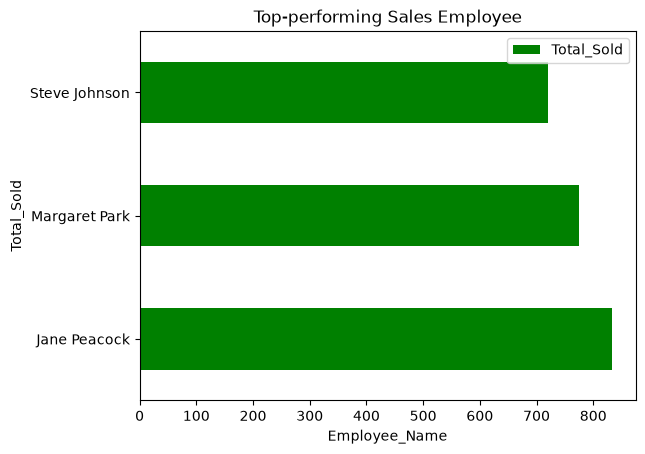

In [8]:
#Visualize at least one result with a bar chart

df.plot(x = 'Employee_Name', y = 'Total_Sold', kind = 'barh', color = 'green')

plt.title('Top-performing Sales Employee')
plt.xlabel('Employee_Name')
plt.ylabel('Total_Sold')
plt.show()